# 23 - Backpropagation for XOR / XNOR

Implement a simple neural network (2-2-1) with backpropagation to learn XOR and XNOR logic functions.

**Problem Statement**

Train a simple neural network using backpropagation to perform XOR and XNOR logic operations. Save a sample CSV and show training, loss curve, and final accuracy.

**Understanding of Dataset**

We use a tiny CSV with `x1`, `x2`, `XOR`, `XNOR`. The network input is two binary features and the target is either XOR or XNOR. A single-layer perceptron cannot learn XOR; a 2-2-1 network with hidden units and non-linear activation can.

**Theory**

Backpropagation computes gradients of loss w.r.t. weights via chain rule and updates weights by gradient descent. With a hidden layer and non-linear activations (sigmoid), the network can model non-linearly separable functions like XOR.

**Mathematical Representation**

For one sample x: z1 = W1 x + b1, a1 = sigmoid(z1), z2 = W2 a1 + b2, y = sigmoid(z2).
Loss (MSE): L = 0.5*(t - y)^2. Gradients: dL/dW2 = (y - t) * y*(1-y) * a1^T, etc.

**Pseudocode**

1. Load CSV -> clean -> prepare X, y for XOR and XNOR
2. Initialize weights W1 (2x2), b1 (2,), W2 (1x2), b2 (1,)
3. For epochs: forward pass -> compute loss -> backward pass -> update weights
4. After training, compute predictions and accuracy; plot loss curve.

In [1]:
# Simple backprop implementation for XOR/XNOR with comments
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Create and save small CSV for XOR/XNOR
df = pd.DataFrame({
    'x1': [0,0,1,1],
    'x2': [0,1,0,1],
})
df['XOR'] = (df['x1'] ^ df['x2']).astype(int)
df['XNOR'] = (1 - df['XOR']).astype(int)
df.to_csv('backprop_xor_sample.csv', index=False)
print('Saved backprop_xor_sample.csv with columns x1,x2,XOR,XNOR')
df

Saved backprop_xor_sample.csv with columns x1,x2,XOR,XNOR


,x1,x2,XOR,XNOR
0,0,0,0,1
1,0,1,1,0
2,1,0,1,0
3,1,1,0,1


In [2]:
# === Load and prepare data ===
data = pd.read_csv('backprop_xor_sample.csv')
# if exam CSV has different column names, rename accordingly
X = data[['x1','x2']].values.astype(float)
y_xor = data['XOR'].values.reshape(-1,1).astype(float)
y_xnor = data['XNOR'].values.reshape(-1,1).astype(float)
print('X:', X)
print('y XOR:', y_xor.ravel())
print('y XNOR:', y_xnor.ravel())

X: [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y XOR: [0. 1. 1. 0.]
y XNOR: [1. 0. 0. 1.]


In [3]:
# === Simple neural network with one hidden layer (2 hidden units) ===
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    return a * (1 - a)

def train_nn(X, y, hidden_size=2, lr=0.5, epochs=5000, verbose=False):
    n_samples, n_inputs = X.shape
    # Initialize weights small random values
    rng = np.random.RandomState(1)
    W1 = rng.randn(n_inputs, hidden_size) * 0.5
    b1 = np.zeros((1, hidden_size))
    W2 = rng.randn(hidden_size, 1) * 0.5
    b2 = np.zeros((1,1))
    losses = []
    for epoch in range(epochs):
        # Forward pass
        z1 = np.dot(X, W1) + b1  # (n_samples, hidden_size)
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2  # (n_samples, 1)
        a2 = sigmoid(z2)  # predictions
        # Compute mean squared error loss (simple)
        loss = np.mean(0.5 * (y - a2)**2)
        losses.append(loss)
        # Backward pass (compute gradients)
        d_a2 = a2 - y  # (n_samples,1)
        d_z2 = d_a2 * sigmoid_deriv(a2)  # (n_samples,1)
        dW2 = np.dot(a1.T, d_z2) / n_samples  # (hidden_size,1)
        db2 = np.sum(d_z2, axis=0, keepdims=True) / n_samples  # (1,1)
        d_a1 = np.dot(d_z2, W2.T)  # (n_samples, hidden_size)
        d_z1 = d_a1 * sigmoid_deriv(a1)  # (n_samples, hidden_size)
        dW1 = np.dot(X.T, d_z1) / n_samples  # (n_inputs, hidden_size)
        db1 = np.sum(d_z1, axis=0, keepdims=True) / n_samples  # (1, hidden_size)
        # Gradient descent update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
        if verbose and (epoch % 1000 == 0):
            print(f'Epoch {epoch}, loss={loss:.6f}')
    params = {'W1':W1, 'b1':b1, 'W2':W2, 'b2':b2}
    return params, losses

def predict_nn(X, params):
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']
    a1 = sigmoid(np.dot(X, W1) + b1)
    a2 = sigmoid(np.dot(a1, W2) + b2)
    return (a2 > 0.5).astype(int), a2

# Train on XOR
params_xor, losses_xor = train_nn(X, y_xor, hidden_size=2, lr=1.0, epochs=5000, verbose=False)
pred_xor, prob_xor = predict_nn(X, params_xor)
acc_xor = accuracy_score(y_xor, pred_xor)
print('XOR accuracy:', acc_xor)
print('Predictions:', pred_xor.ravel(), 'Targets:', y_xor.ravel())

# Train on XNOR
params_xnor, losses_xnor = train_nn(X, y_xnor, hidden_size=2, lr=1.0, epochs=5000, verbose=False)
pred_xnor, prob_xnor = predict_nn(X, params_xnor)
acc_xnor = accuracy_score(y_xnor, pred_xnor)
print('XNOR accuracy:', acc_xnor)
print('Predictions:', pred_xnor.ravel(), 'Targets:', y_xnor.ravel())

XOR accuracy: 1.0
Predictions: [0 1 1 0] Targets: [0. 1. 1. 0.]
XNOR accuracy: 1.0
Predictions: [1 0 0 1] Targets: [1. 0. 0. 1.]


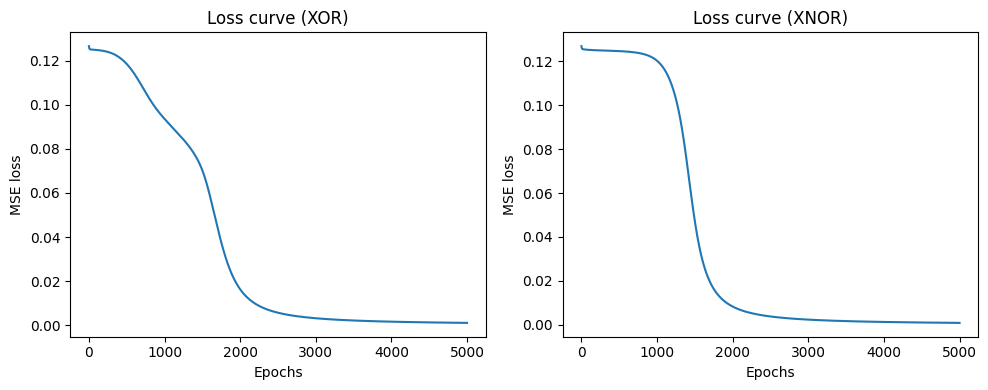

Saved results to backprop_xor_results.csv


In [4]:
# === Plot loss curves ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(losses_xor)
plt.title('Loss curve (XOR)')
plt.xlabel('Epochs')
plt.ylabel('MSE loss')
plt.subplot(1,2,2)
plt.plot(losses_xnor)
plt.title('Loss curve (XNOR)')
plt.xlabel('Epochs')
plt.ylabel('MSE loss')
plt.tight_layout()
plt.show()

# Save parameters and predictions to CSV for inspection
out = data.copy()
out['pred_xor'] = pred_xor.ravel()
out['pred_xnor'] = pred_xnor.ravel()
out.to_csv('backprop_xor_results.csv', index=False)
print('Saved results to backprop_xor_results.csv')

**Evaluation Matrix**

- Reported training accuracy for XOR and XNOR. For larger datasets use precision/recall and validation set.

**Notes for different datasets / exam CSV**

- Replace `pd.read_csv('backprop_xor_sample.csv')` with the provided CSV.
- Ensure input features are numeric and scaled if ranges differ.
- For more inputs, adjust input layer size and hidden layer size accordingly.
- For classification with more classes, use softmax in output and cross-entropy loss.